<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-stress-factors-analysis-ml-93-27?scriptVersionId=270508549" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/analyzing-student-stress-factors/Student Stress Factors (2).csv


## title = "Student Stress Factors Analysis"

## # Detailed Description
description = """
This project aims to analyze various factors contributing to student stress levels.
The dataset includes features such as study hours, sleep duration, academic performance,
attendance, extracurricular involvement, and mental health indicators. The goal is to
identify key patterns and correlations that influence student stress, enabling educators
and institutions to take data-driven measures to support student well-being.

Key Objectives:
1. Understand relationships between academic and lifestyle variables affecting stress.
2. Apply data visualization techniques to explore patterns.
3. Use machine learning models to predict stress levels based on influencing factors.
4. Provide actionable insights for improving student health and productivity.
"""

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/analyzing-student-stress-factors/Student Stress Factors (2).csv")

In [3]:
df.head()

,Kindly Rate your Sleep Quality 😴,How many times a week do you suffer headaches 🤕?,How would you rate you academic performance 👩‍🎓?,how would you rate your study load?,How many times a week you practice extracurricular activities 🎾?,How would you rate your stress levels?
0,3,1,3,4,2,3
1,4,1,2,3,3,2
2,2,1,2,1,4,4
3,3,2,3,2,3,3
4,2,3,1,5,5,3


In [4]:
df.tail()

,Kindly Rate your Sleep Quality 😴,How many times a week do you suffer headaches 🤕?,How would you rate you academic performance 👩‍🎓?,how would you rate your study load?,How many times a week you practice extracurricular activities 🎾?,How would you rate your stress levels?
515,3,2,4,2,3,1
516,2,4,3,2,1,2
517,2,3,5,1,5,2
518,3,4,3,5,2,5
519,5,1,5,5,5,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column                                                            Non-Null Count  Dtype
---  ------                                                            --------------  -----
 0   Kindly Rate your Sleep Quality 😴                                  520 non-null    int64
 1   How many times a week do you suffer headaches 🤕?                  520 non-null    int64
 2   How would you rate you academic performance 👩‍🎓?                  520 non-null    int64
 3   how would you rate your study load?                               520 non-null    int64
 4   How many times a week you practice extracurricular activities 🎾?  520 non-null    int64
 5   How would you rate your stress levels?                            520 non-null    int64
dtypes: int64(6)
memory usage: 24.5 KB


In [6]:
df.describe()

,Kindly Rate your Sleep Quality 😴,How many times a week do you suffer headaches 🤕?,How would you rate you academic performance 👩‍🎓?,how would you rate your study load?,How many times a week you practice extracurricular activities 🎾?,How would you rate your stress levels?
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,3.125000,2.182692,3.326923,2.750000,2.682692,2.875000
std,1.099023,1.247459,1.061158,1.372381,1.470745,1.357825
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000
50%,3.000000,2.000000,3.000000,2.500000,3.000000,3.000000
75%,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
df.dtypes

Kindly Rate your Sleep Quality 😴                                    int64
How many times a week do you suffer headaches 🤕?                    int64
How would you rate you academic performance 👩‍🎓?                    int64
how would you rate your study load?                                 int64
How many times a week you practice extracurricular activities 🎾?    int64
How would you rate your stress levels?                              int64
dtype: object

In [8]:
df.shape

(520, 6)

In [9]:
df.isnull().sum()

Kindly Rate your Sleep Quality 😴                                    0
How many times a week do you suffer headaches 🤕?                    0
How would you rate you academic performance 👩‍🎓?                    0
how would you rate your study load?                                 0
How many times a week you practice extracurricular activities 🎾?    0
How would you rate your stress levels?                              0
dtype: int64

In [10]:
df.duplicated().sum()

416

In [11]:
df.nunique()

Kindly Rate your Sleep Quality 😴                                    5
How many times a week do you suffer headaches 🤕?                    5
How would you rate you academic performance 👩‍🎓?                    5
how would you rate your study load?                                 5
How many times a week you practice extracurricular activities 🎾?    5
How would you rate your stress levels?                              5
dtype: int64

In [12]:
df.describe().loc[['min','max','mean']]

,Kindly Rate your Sleep Quality 😴,How many times a week do you suffer headaches 🤕?,How would you rate you academic performance 👩‍🎓?,how would you rate your study load?,How many times a week you practice extracurricular activities 🎾?,How would you rate your stress levels?
min,1.000,1.000000,1.000000,1.00,1.000000,1.000
max,5.000,5.000000,5.000000,5.00,5.000000,5.000
mean,3.125,2.182692,3.326923,2.75,2.682692,2.875


In [13]:
df.columns

Index(['Kindly Rate your Sleep Quality 😴',
       'How many times a week do you suffer headaches 🤕?',
       'How would you rate you academic performance 👩‍🎓?',
       'how would you rate your study load?',
       'How many times a week you practice extracurricular activities 🎾?',
       'How would you rate your stress levels?'],
      dtype='object')

In [14]:
df.columns = ['Sleep_Quality', 'Headache_Frequency', 'Academic_Performance',
              'Study_Load', 'Extracurricular_Freq', 'Stress_Level']

# 🧩 Convert to numeric if possible
df = df.apply(pd.to_numeric, errors='ignore')

# Set visualization theme
sns.set(style="whitegrid", palette="coolwarm")

## Data visualizations

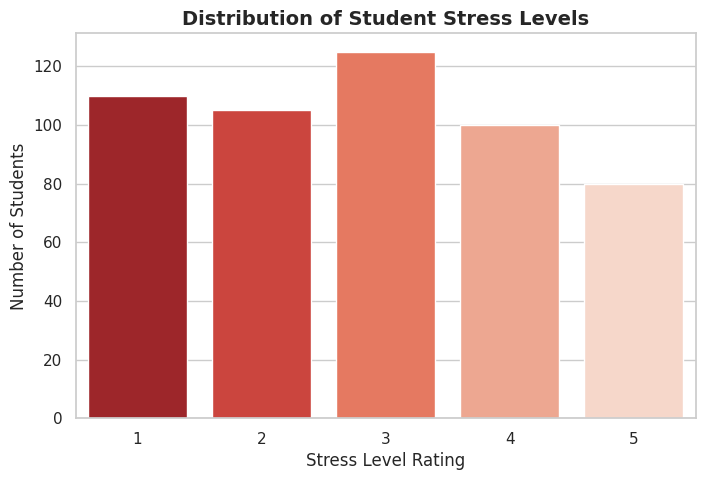

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Stress_Level', data=df, palette='Reds_r')
plt.title('Distribution of Student Stress Levels', fontsize=14, weight='bold')
plt.xlabel('Stress Level Rating')
plt.ylabel('Number of Students')
plt.show()

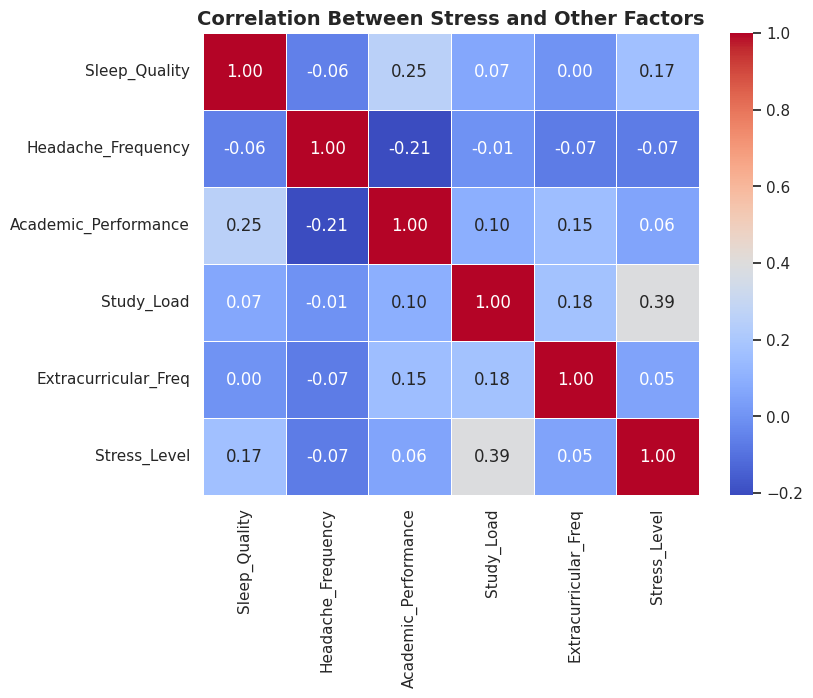

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Stress and Other Factors', fontsize=14, weight='bold')
plt.show()

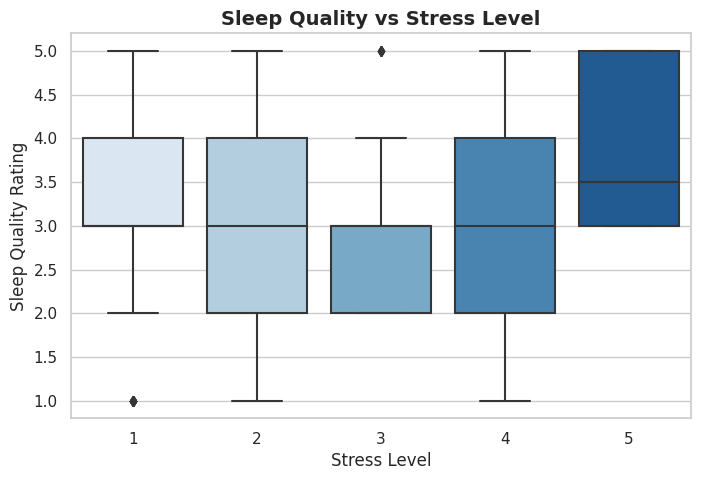

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Stress_Level', y='Sleep_Quality', data=df, palette='Blues')
plt.title('Sleep Quality vs Stress Level', fontsize=14, weight='bold')
plt.xlabel('Stress Level')
plt.ylabel('Sleep Quality Rating')
plt.show()

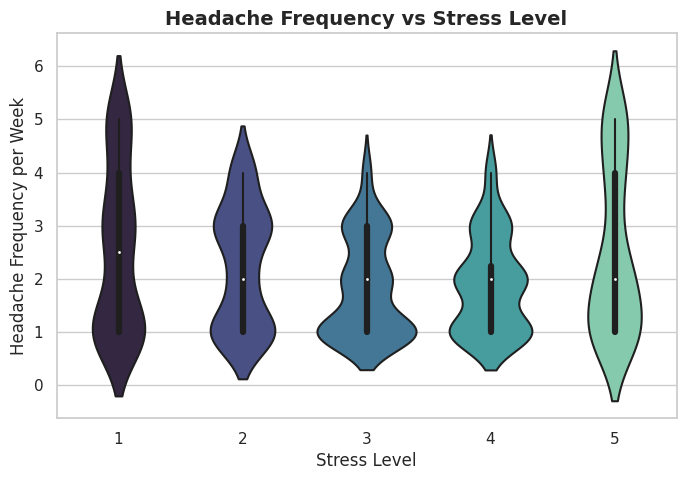

In [18]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Stress_Level', y='Headache_Frequency', data=df, palette='mako')
plt.title('Headache Frequency vs Stress Level', fontsize=14, weight='bold')
plt.xlabel('Stress Level')
plt.ylabel('Headache Frequency per Week')
plt.show()

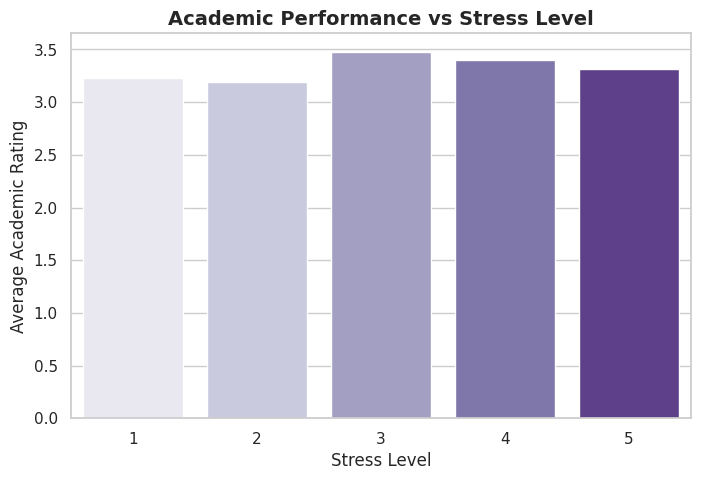

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x='Stress_Level', y='Academic_Performance', data=df, ci=None, palette='Purples')
plt.title('Academic Performance vs Stress Level', fontsize=14, weight='bold')
plt.xlabel('Stress Level')
plt.ylabel('Average Academic Rating')
plt.show()


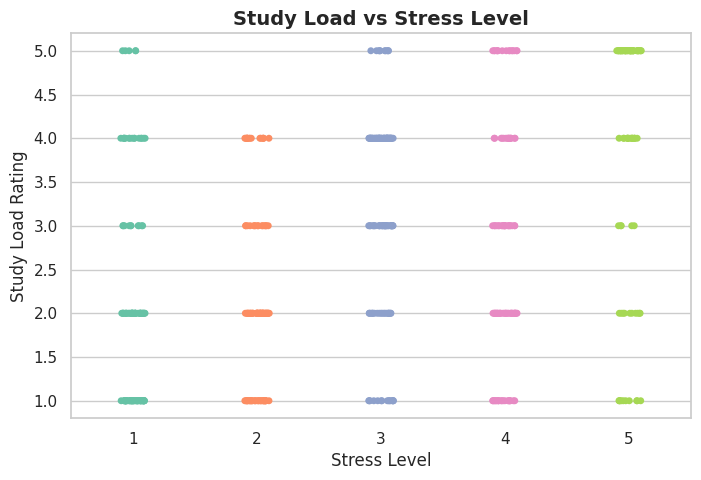

In [20]:
plt.figure(figsize=(8,5))
sns.stripplot(x='Stress_Level', y='Study_Load', data=df, jitter=True, palette='Set2')
plt.title('Study Load vs Stress Level', fontsize=14, weight='bold')
plt.xlabel('Stress Level')
plt.ylabel('Study Load Rating')
plt.show()

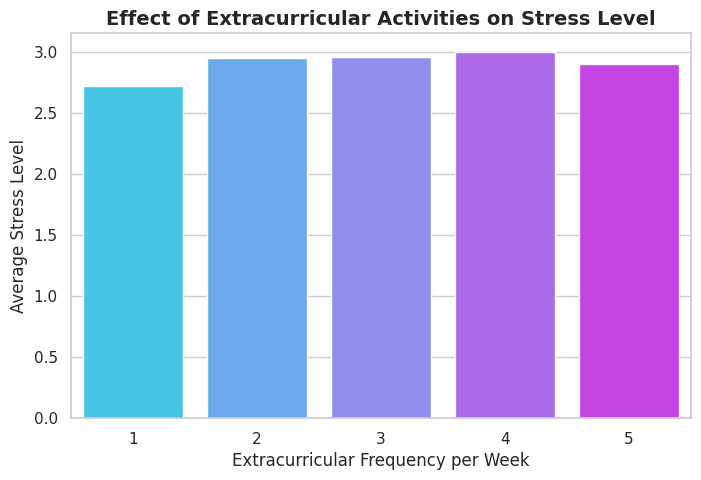

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x='Extracurricular_Freq', y='Stress_Level', data=df, ci=None, palette='cool')
plt.title('Effect of Extracurricular Activities on Stress Level', fontsize=14, weight='bold')
plt.xlabel('Extracurricular Frequency per Week')
plt.ylabel('Average Stress Level')
plt.show()

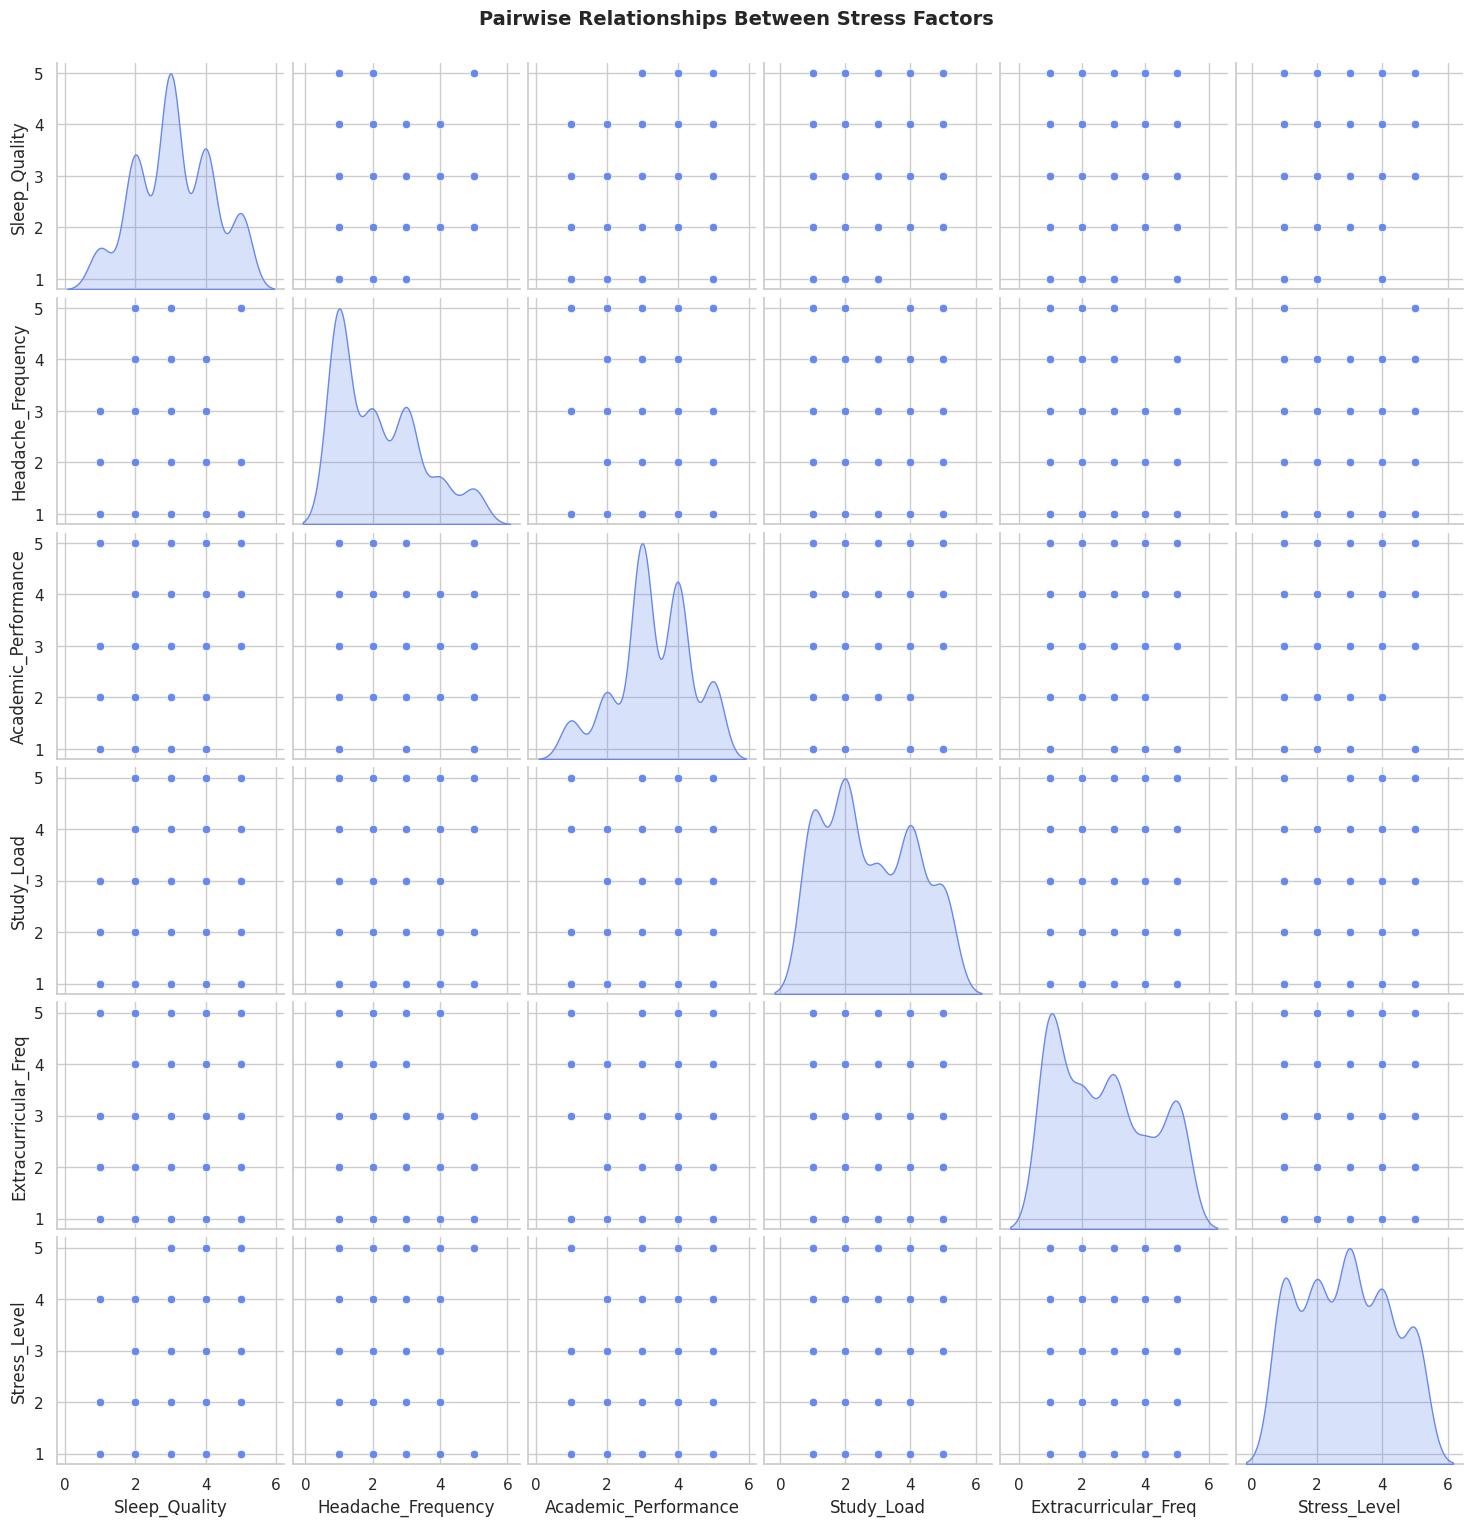

In [22]:
sns.pairplot(df, diag_kind='kde', palette='viridis')
plt.suptitle('Pairwise Relationships Between Stress Factors', y=1.02, fontsize=14, weight='bold')
plt.show()

## Ml algorithms

In [23]:
df.columns = [
    'Sleep_Quality', 
    'Headaches_per_Week', 
    'Academic_Performance', 
    'Study_Load', 
    'Extracurricular_Frequency', 
    'Stress_Level'
]

print('\nRenamed Columns:')
print(df.columns.tolist())

# Verify the types of the columns, note that all are numeric.
print('\nData types of each column:')
print(df.dtypes)


Renamed Columns:
['Sleep_Quality', 'Headaches_per_Week', 'Academic_Performance', 'Study_Load', 'Extracurricular_Frequency', 'Stress_Level']

Data types of each column:
Sleep_Quality                int64
Headaches_per_Week           int64
Academic_Performance         int64
Study_Load                   int64
Extracurricular_Frequency    int64
Stress_Level                 int64
dtype: object


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [26]:
encoder = LabelEncoder()
for col in df.columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [27]:
features = ['Sleep_Quality', 'Headaches_per_Week', 'Academic_Performance',
             'Study_Load', 'Extracurricular_Frequency']
target = 'Stress_Level'

X = df[features]
y = df[target]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [30]:
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 37.50%
Decision Tree Accuracy: 93.27%
Random Forest Accuracy: 93.27%
KNN Accuracy: 85.58%
SVM Accuracy: 65.38%
Naive Bayes Accuracy: 41.35%
Gradient Boosting Accuracy: 91.35%


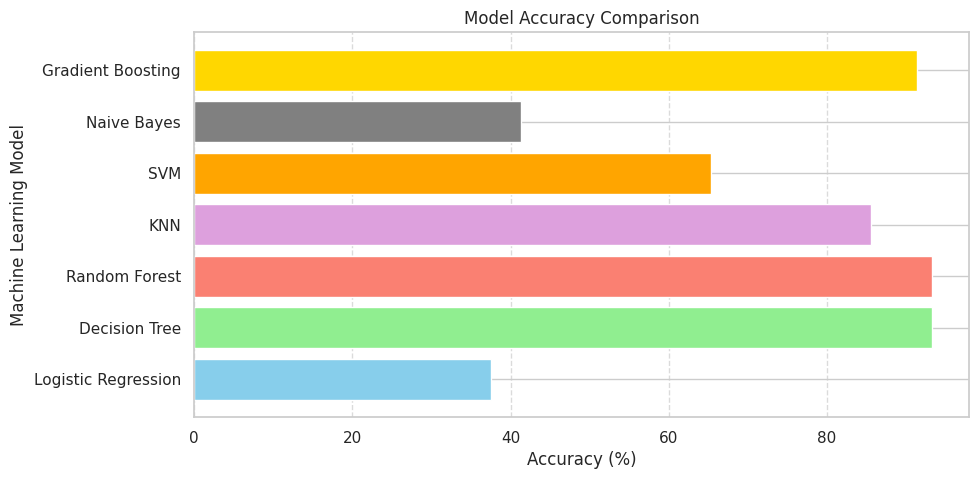

In [31]:
plt.figure(figsize=(10, 5))
plt.barh(list(accuracies.keys()), list(accuracies.values()), color=['skyblue', 'lightgreen', 'salmon', 'plum', 'orange', 'gray', 'gold'])
plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Model")
plt.title("Model Accuracy Comparison")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Thank you...pls upvote!!!